In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import font_manager
from pathlib import Path

import torch

# Drop the .ttf/.otf anywhere in your workspace, e.g. ./fonts/Inter-Regular.ttf
font_dir = Path("/home/aid/dkoh/fonts/PlusJakartaSans")
for font_file in font_dir.rglob("*.[ot]tf"):  # picks up .ttf and .otf
    font_manager.fontManager.addfont(str(font_file))
font_dir = Path("/home/aid/dkoh/fonts/JetBrainsMono")
for font_file in font_dir.rglob("*.[ot]tf"):  # picks up .ttf and .otf
    font_manager.fontManager.addfont(str(font_file))

# Optional: see what got registered
registered = {f.name for f in font_manager.fontManager.ttflist}
print(sorted(registered))

from matplotlib import rcParams

PUB_STYLE = {
    "font.family": "Plus Jakarta Sans",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False,
    "figure.dpi": 120,
}

DATASET_COLORS = {
    "public":   "#0D4A70",  # dark grey, slightly warm
    "extra":    "#FFC61E",  # muted navy blue
    "in_house": "#FF1F5B",  # brick red, desaturated
}

rcParams.update(PUB_STYLE)

['Abyssinica SIL', 'Ani', 'AnjaliOldLipi', 'C059', 'Chandas', 'Chilanka', 'D050000L', 'DejaVu Math TeX Gyre', 'DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Serif Display', 'Dhurjati', 'Droid Sans Fallback', 'Dyuthi', 'FreeMono', 'FreeSans', 'FreeSerif', 'Gargi', 'Garuda', 'Gayathri', 'Gidugu', 'Gubbi', 'Gurajada', 'Jamrul', 'JetBrains Mono', 'JetBrains Mono NL', 'KacstArt', 'KacstBook', 'KacstDecorative', 'KacstDigital', 'KacstFarsi', 'KacstLetter', 'KacstNaskh', 'KacstOffice', 'KacstOne', 'KacstPen', 'KacstPoster', 'KacstQurn', 'KacstScreen', 'KacstTitle', 'KacstTitleL', 'Kalapi', 'Kalimati', 'Karumbi', 'Keraleeyam', 'Khmer OS', 'Khmer OS System', 'Kinnari', 'LKLUG', 'LakkiReddy', 'Laksaman', 'Liberation Mono', 'Liberation Sans', 'Liberation Sans Narrow', 'Liberation Serif', 'Likhan', 'Lohit Assamese', 'Lohit Bengali', 'Lohit Devanagari', 'Lohit Gujarati', 'Lohit Gurmukhi', 'Lohit Kannada', 'Lohit Malayalam', 'Lohit Odia', 'Lohit Tamil', 'Lohit Tami

In [2]:
df = pd.read_csv('/home/aid/dkoh/log/generative/BBB/lrrk2_RTB_Denovo_20260601_173926/metrics.csv')

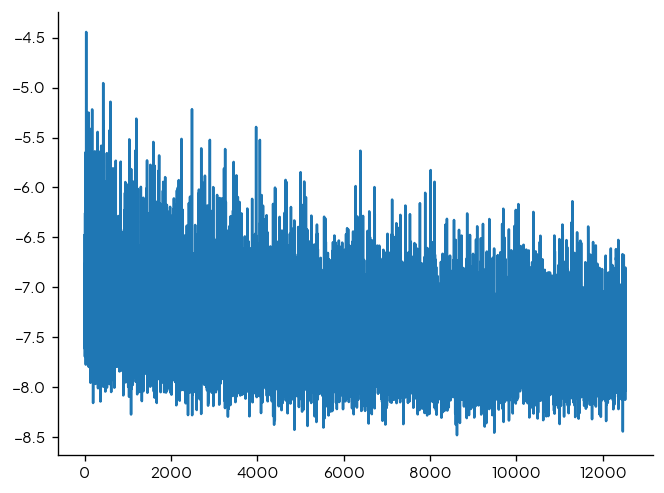

In [3]:
fig, ax = plt.subplots()
ax.plot(np.arange(df.shape[0]), df['Average QedxSaxDock score online'])

In [4]:
df

,Total loss,logZ,online_loss,Average Overall Reward,Average norm QedxSaxDock rew online,Average QedxSaxDock score online,Percent_valid_mols,Percent_unique_in_batch,Percent_novel_cumulative,Top-10 mean reward,...,Avg. Num_Rings Online,Avg. SAS onln,Avg. QED onln,Zinc Radius Online,Train_iter,Time elapsed,Percentage of generated molecules passing BBB threshold,Average BBB score,Percentage of generated molecules passing solubility threshold,Average solubility LogS
0,23684.248047,-84.443069,23684.248047,0.182939,0.284476,-6.478875,100.0,100.0,100.0000,0.271337,...,2.2500,4.182433,0.744965,0.881647,0,7.183607,31.25,0.737908,81.25,-2.936899
1,2069.592773,-84.443069,2069.592773,0.239610,0.414209,-7.566937,100.0,100.0,100.0000,0.348201,...,2.5625,4.386312,0.729475,0.881432,1,10.240783,37.50,0.756491,75.00,-3.116609
2,3890.893555,-84.443069,3890.893555,0.173647,0.323509,-7.605250,100.0,100.0,100.0000,0.361934,...,2.3125,4.164124,0.695706,0.885536,2,13.087785,12.50,0.591988,81.25,-2.801814
3,9854.206055,-84.443069,9854.206055,0.184371,0.341073,-6.922813,100.0,100.0,100.0000,0.371260,...,3.0625,4.830665,0.736907,0.862002,3,17.472728,18.75,0.652176,87.50,-2.937155
4,16085.075195,-85.087143,16085.075195,0.164826,0.306253,-6.764500,100.0,100.0,100.0000,0.384731,...,2.6875,5.002125,0.705860,0.840636,4,23.855935,18.75,0.617993,81.25,-3.107864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12527,885.350586,-82.883934,885.350586,0.373710,0.467484,-7.429937,100.0,100.0,95.3125,0.786284,...,3.1250,3.360744,0.724509,0.946262,12527,53520.923244,62.50,0.826282,100.00,-2.818058
12528,2526.393066,-69.697594,2526.393066,0.410291,0.503926,-7.587688,100.0,100.0,100.0000,0.786284,...,3.4375,3.308930,0.761341,0.955418,12528,53526.016958,75.00,0.887348,87.50,-3.124767
12529,863.986755,-69.697594,863.986755,0.407080,0.516713,-7.571000,100.0,100.0,100.0000,0.786284,...,3.3125,3.325111,0.762523,0.965738,12529,53529.370906,87.50,0.946426,93.75,-3.148782
12530,2336.280273,-69.697594,2336.280273,0.403960,0.523757,-8.035500,100.0,100.0,100.0000,0.786284,...,3.6875,3.485482,0.783795,0.965814,12530,53532.471977,68.75,0.900383,87.50,-2.919319


In [19]:
df = pd.read_parquet('/media/aid/s1/BindingDB/fragments/BindingDB_single_chain_001.parquet')